In this project, the **CRISP-DM (Cross-Industry Standard Process for Data Mining)** methodology has been used.


https://www.sv-europe.com/crisp-dm-methodology/


### 1.Business Understanding

Objective: Predict customer churn for a telecom company to improve customer retention and revenue.

Goal: Identify at-risk customers using historical usage, complaints, subscription, and demographic data.

Impact: Reducing churn could improve revenue and customer loyalty.

Notes: Clear problem definition and business relevance. Good job linking churn to potential business outcomes.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

### 2.Data Understanding

Dataset: Customer Churn.csv with 3,150 rows and 14 columns.

Target Variable: Churn (0 = no churn, 1 = churn)

Data Types: Mostly numeric; no missing values.

In [3]:
data = pd.read_csv("Customer Churn.csv")
data

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3145,21,0,19,2,6697,147,92,44,2,2,1,25,721.980,0
3146,17,0,17,1,9237,177,80,42,5,1,1,55,261.210,0
3147,13,0,18,4,3157,51,38,21,3,1,1,30,280.320,0
3148,7,0,11,2,4695,46,222,12,3,1,1,30,1077.640,0


In [4]:
data.shape

(3150, 14)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  Churn                    3150 non-null   int64  
dtypes: float64(1), int64(13)

In [6]:
data.isnull().sum()

Call  Failure              0
Complains                  0
Subscription  Length       0
Charge  Amount             0
Seconds of Use             0
Frequency of use           0
Frequency of SMS           0
Distinct Called Numbers    0
Age Group                  0
Tariff Plan                0
Status                     0
Age                        0
Customer Value             0
Churn                      0
dtype: int64

In [7]:
data.describe()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
count,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000
mean,7.627937,0.076508,32.541905,0.942857,4472.459683,69.460635,73.174921,23.509841,2.826032,1.077778,1.248254,30.998413,470.972916,0.157143
std,7.263886,0.265851,8.573482,1.521072,4197.908687,57.413308,112.237560,17.217337,0.892555,0.267864,0.432069,8.831095,517.015433,0.363993
min,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,15.000000,0.000000,0.000000
25%,1.000000,0.000000,30.000000,0.000000,1391.250000,27.000000,6.000000,10.000000,2.000000,1.000000,1.000000,25.000000,113.801250,0.000000
50%,6.000000,0.000000,35.000000,0.000000,2990.000000,54.000000,21.000000,21.000000,3.000000,1.000000,1.000000,30.000000,228.480000,0.000000
75%,12.000000,0.000000,38.000000,1.000000,6478.250000,95.000000,87.000000,34.000000,3.000000,1.000000,1.000000,30.000000,788.388750,0.000000
max,36.000000,1.000000,47.000000,10.000000,17090.000000,255.000000,522.000000,97.000000,5.000000,2.000000,2.000000,55.000000,2165.280000,1.000000


In [8]:
# Numeric columns
data_numeric = data.select_dtypes(include='number')

In [9]:

print("\n Statistical summary of numerical variables:")
data_numeric.describe()


 Statistical summary of numerical variables:


,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
count,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000
mean,7.627937,0.076508,32.541905,0.942857,4472.459683,69.460635,73.174921,23.509841,2.826032,1.077778,1.248254,30.998413,470.972916,0.157143
std,7.263886,0.265851,8.573482,1.521072,4197.908687,57.413308,112.237560,17.217337,0.892555,0.267864,0.432069,8.831095,517.015433,0.363993
min,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,15.000000,0.000000,0.000000
25%,1.000000,0.000000,30.000000,0.000000,1391.250000,27.000000,6.000000,10.000000,2.000000,1.000000,1.000000,25.000000,113.801250,0.000000
50%,6.000000,0.000000,35.000000,0.000000,2990.000000,54.000000,21.000000,21.000000,3.000000,1.000000,1.000000,30.000000,228.480000,0.000000
75%,12.000000,0.000000,38.000000,1.000000,6478.250000,95.000000,87.000000,34.000000,3.000000,1.000000,1.000000,30.000000,788.388750,0.000000
max,36.000000,1.000000,47.000000,10.000000,17090.000000,255.000000,522.000000,97.000000,5.000000,2.000000,2.000000,55.000000,2165.280000,1.000000


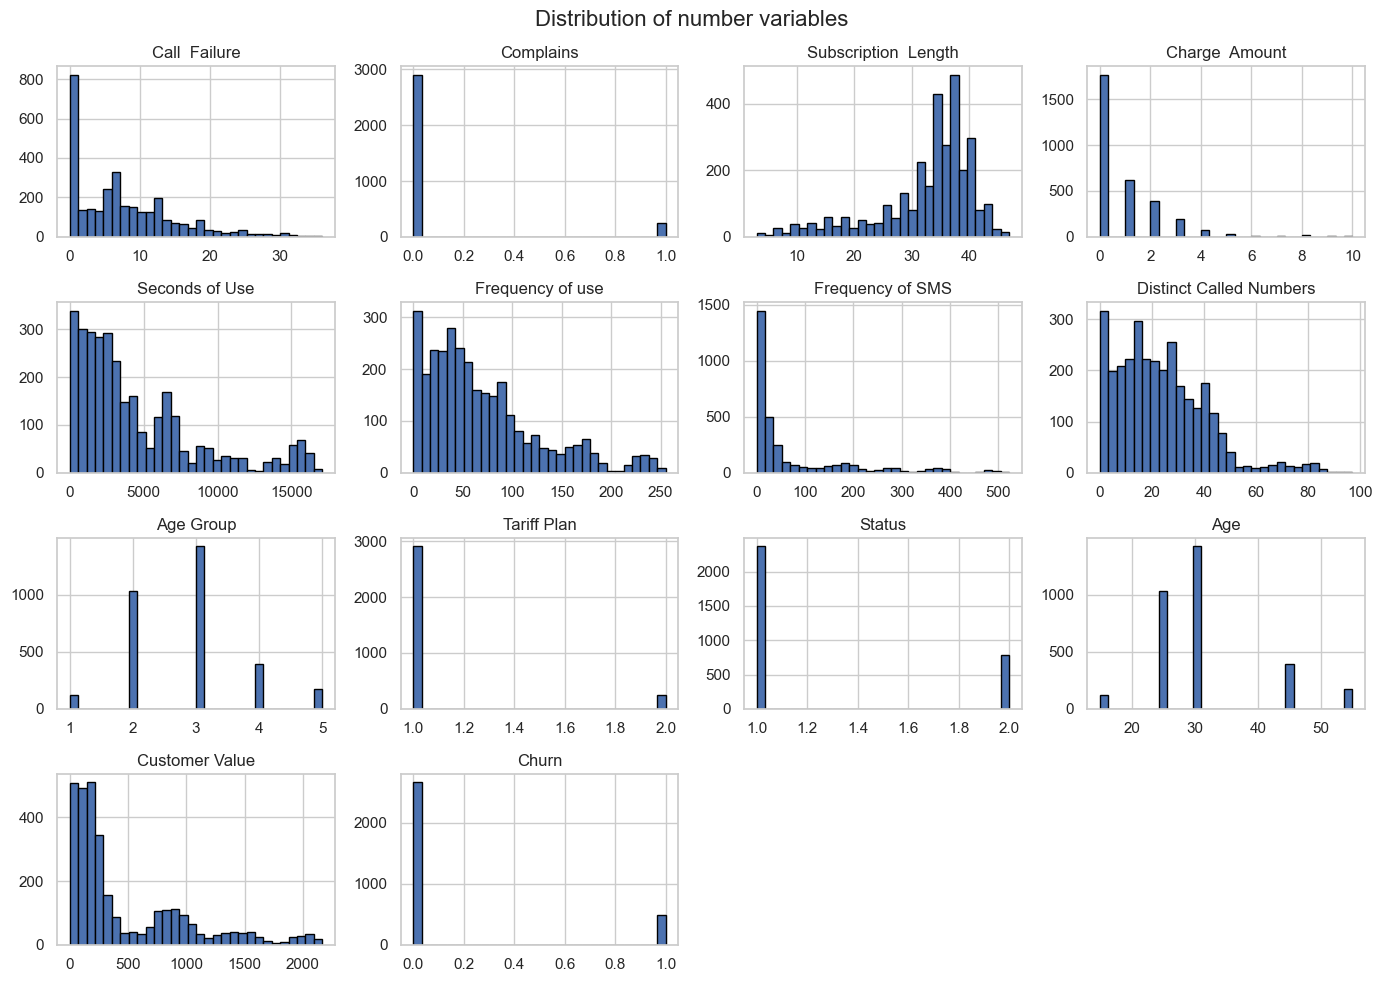

In [10]:
sns.set(style="whitegrid")

# Histogram
data_numeric.hist(figsize=(14, 10), bins=30, edgecolor='black')
plt.suptitle("Distribution of number variables", fontsize=16)
plt.tight_layout()
plt.show()


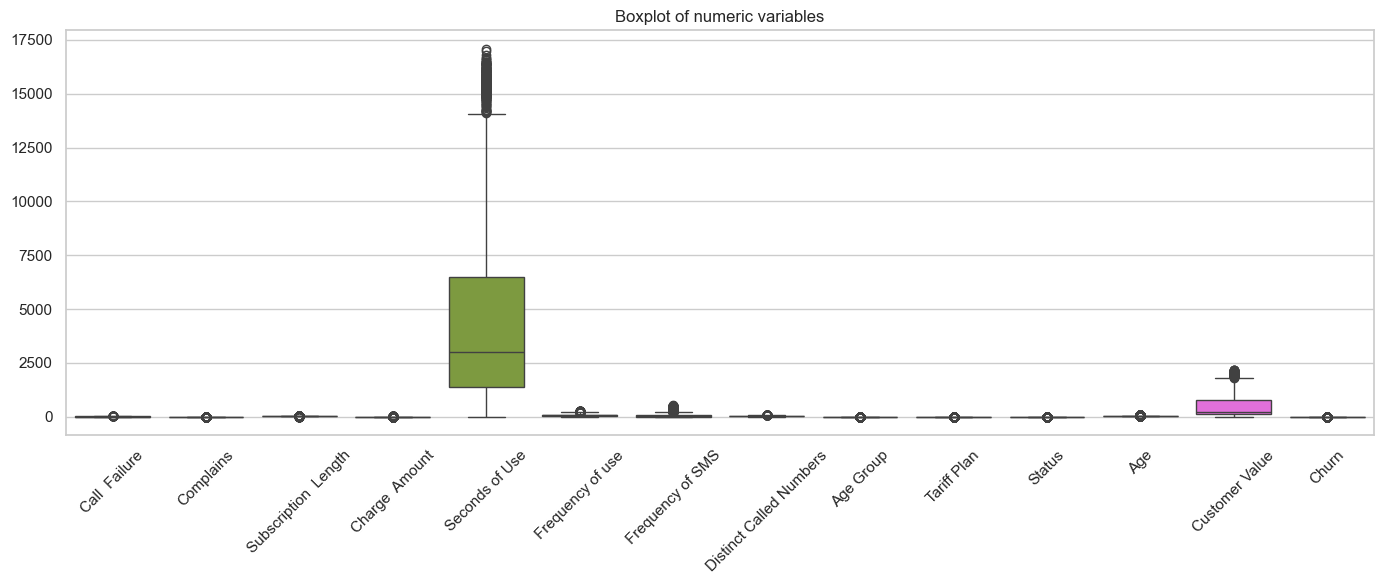

In [11]:
# Boxplot to compare outliers
plt.figure(figsize=(14, 6))
sns.boxplot(data=data_numeric)
plt.xticks(rotation=45)
plt.title("Boxplot of numeric variables")
plt.tight_layout()
plt.show()


In [12]:
categorical_vars = ['Complains', 'Charge  Amount', 'Age Group', 'Tariff Plan', 'Status', 'Churn']

for var in categorical_vars:
    print(f"Value counts for {var}:")
    print(data[var].value_counts())
    print("\n" + "-"*50 + "\n")

Value counts for Complains:
Complains
0    2909
1     241
Name: count, dtype: int64

--------------------------------------------------

Value counts for Charge  Amount:
Charge  Amount
0     1768
1      617
2      395
3      199
4       76
5       30
8       19
9       14
7       14
6       11
10       7
Name: count, dtype: int64

--------------------------------------------------

Value counts for Age Group:
Age Group
3    1425
2    1037
4     395
5     170
1     123
Name: count, dtype: int64

--------------------------------------------------

Value counts for Tariff Plan:
Tariff Plan
1    2905
2     245
Name: count, dtype: int64

--------------------------------------------------

Value counts for Status:
Status
1    2368
2     782
Name: count, dtype: int64

--------------------------------------------------

Value counts for Churn:
Churn
0    2655
1     495
Name: count, dtype: int64

--------------------------------------------------



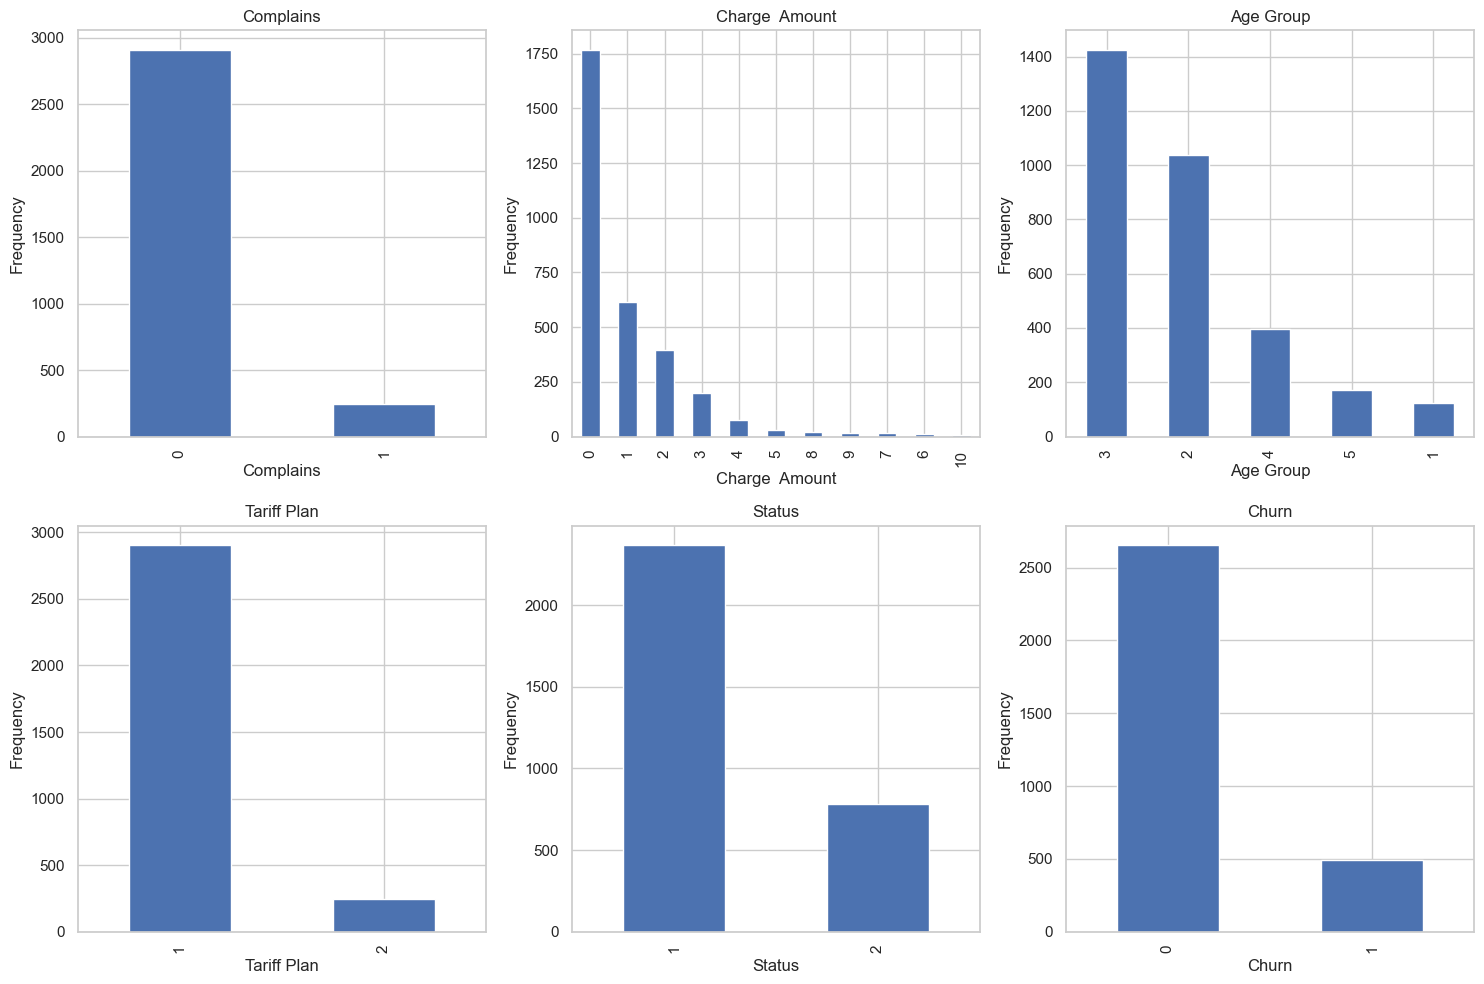

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, var in enumerate(categorical_vars):
    data[var].value_counts().plot(kind='bar', ax=axes[i], title=var)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [14]:
# ایجاد جدول توافقی برای هر متغیر با Churn
for var in categorical_vars:
    if var != 'Churn':
        cross_tab = pd.crosstab(data[var], data['Churn'])
        print(f"Cross tabulation between {var} and Churn:")
        print(cross_tab)
        print("\n")
        

Cross tabulation between Complains and Churn:
Churn         0    1
Complains           
0          2614  295
1            41  200


Cross tabulation between Charge  Amount and Churn:
Churn              0    1
Charge  Amount           
0               1347  421
1                574   43
2                372   23
3                192    7
4                 75    1
5                 30    0
6                 11    0
7                 14    0
8                 19    0
9                 14    0
10                 7    0


Cross tabulation between Age Group and Churn:
Churn         0    1
Age Group           
1           123    0
2           853  184
3          1195  230
4           316   79
5           168    2


Cross tabulation between Tariff Plan and Churn:
Churn           0    1
Tariff Plan           
1            2416  489
2             239    6


Cross tabulation between Status and Churn:
Churn      0    1
Status           
1       2243  125
2        412  370





 Churn class distribution:
 Churn
0    2655
1     495
Name: count, dtype: int64


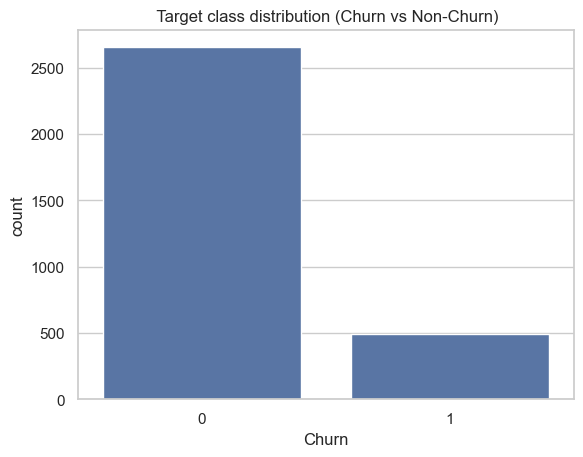

In [15]:
print("\n Churn class distribution:\n", data['Churn'].value_counts())
sns.countplot(x='Churn', data=data)
plt.title(" Target class distribution (Churn vs Non-Churn)")
plt.show()

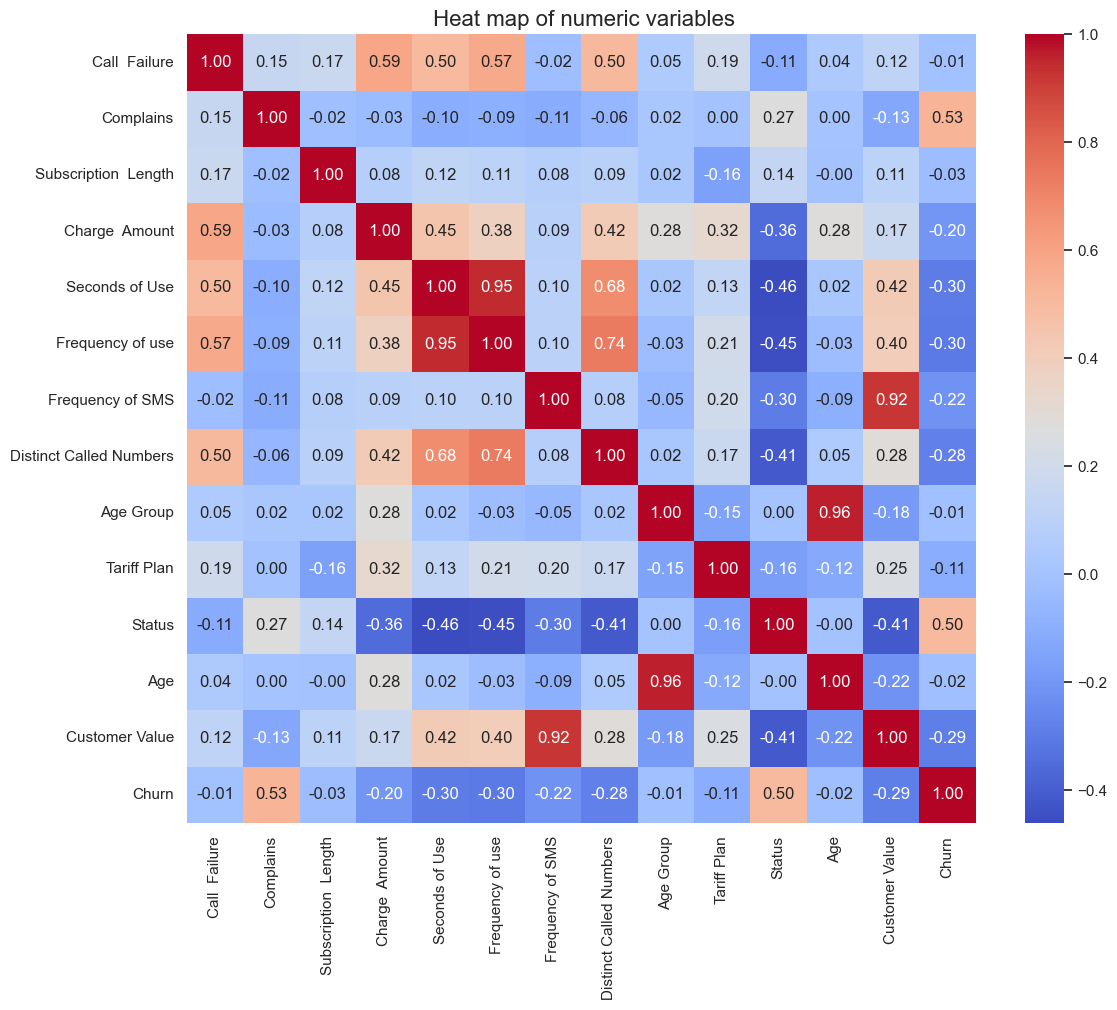

In [16]:
#Correlation
corr_matrix = data_numeric.corr()

# Heat map
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title(" Heat map of numeric variables", fontsize=16)
plt.tight_layout()
plt.show()


### 3.Data Preparation

Splitting: 70% train / 30% test, stratified by churn.

Features: 13 numeric features, no explicit categorical features in this case.

Preprocessing:

StandardScaler for numeric features.

OneHotEncoder for categorical features (none in dataset, so this is effectively skipped).

Pipeline ready for modeling.

Observations:

Preprocessing is clean; scaling is essential for SVM and Logistic Regression.

No missing data; simple imputation was not required

In [17]:
X = data.drop("Churn", axis=1)
y = data["Churn"]


In [18]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numeric Features:", numeric_features.tolist())
print("Categorical Features:", categorical_features.tolist())


Numeric Features: ['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount', 'Seconds of Use', 'Frequency of use', 'Frequency of SMS', 'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age', 'Customer Value']
Categorical Features: []


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (2205, 13)
Test Shape: (945, 13)


In [20]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)


### 4.Modeling

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42
    ),
    
    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ),
    
    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
        random_state=42
    )
}



In [22]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:,1]
    
    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
)

results_df.sort_values(by="ROC-AUC", ascending=False, inplace=True)
print(results_df)


                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
3              XGBoost  0.967196   0.867925  0.932432  0.899023  0.991480
1        Random Forest  0.950265   0.874074  0.797297  0.833922  0.984630
2                  SVM  0.863492   0.536965  0.932432  0.681481  0.968399
0  Logistic Regression  0.837037   0.488722  0.878378  0.628019  0.928325


Observations:

XGBoost outperforms others in all metrics, particularly ROC-AUC.

SVM shows high recall but low precision (likely overpredicts churn).

Random Forest is close to XGBoost but slightly lower in ROC-AUC.

### 5.Evaluation

In [23]:
best_model_name = results_df.iloc[0]["Model"]
print("Best Model:", best_model_name)

best_model = models[best_model_name]

best_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", best_model)
])

best_pipe.fit(X_train, y_train)


Best Model: XGBoost


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


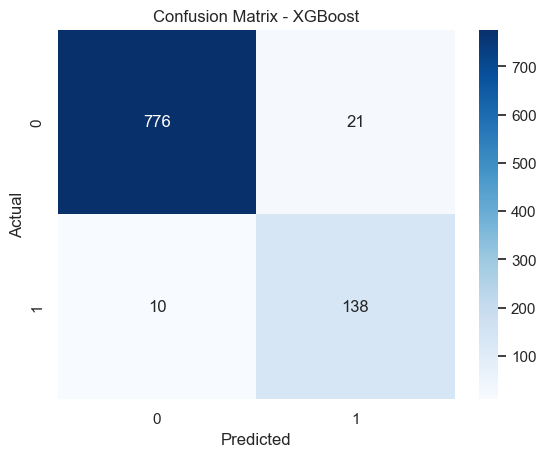

In [24]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_best = best_pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()


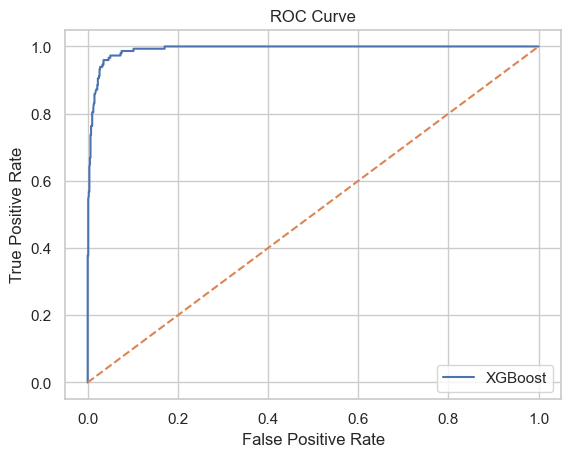

In [25]:
# ROC Curve

from sklearn.metrics import roc_curve

y_prob_best = best_pipe.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob_best)

plt.plot(fpr, tpr, label=best_model_name)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


                    Feature  Importance
10                   Status    0.502310
1                 Complains    0.268957
4            Seconds of Use    0.043645
7   Distinct Called Numbers    0.037523
5          Frequency of use    0.026906
0             Call  Failure    0.026598
2      Subscription  Length    0.026209
8                 Age Group    0.020668
12           Customer Value    0.019757
6          Frequency of SMS    0.018424
3            Charge  Amount    0.009003
9               Tariff Plan    0.000000
11                      Age    0.000000


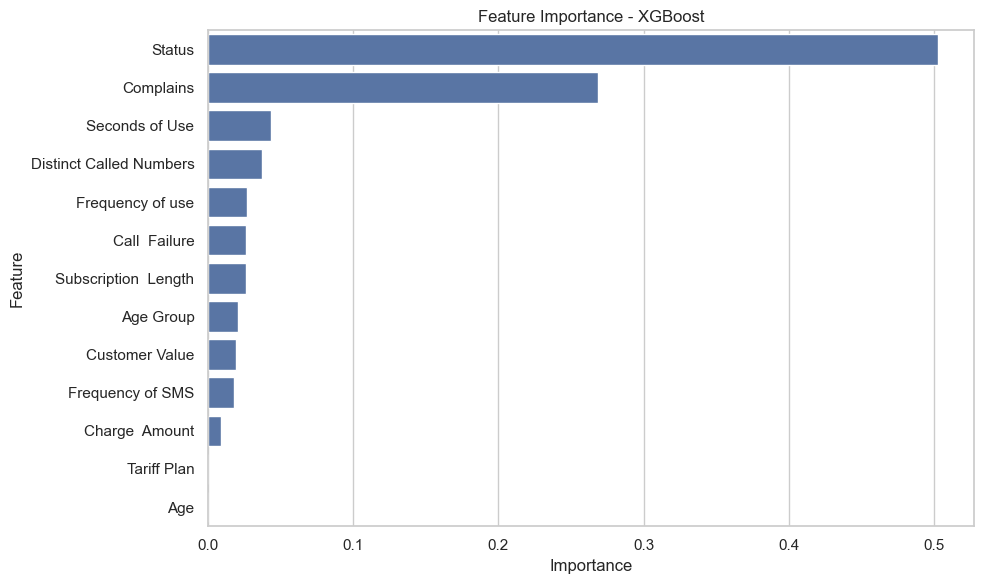

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


feature_importances = best_pipe.named_steps['classifier'].feature_importances_
feature_names = X_train.columns


fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)


print(fi_df)

# Feature Importance plot
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=fi_df)
plt.title('Feature Importance - XGBoost')
plt.tight_layout()
plt.show()


### 6.Deployment

In [27]:
import joblib

joblib.dump(best_pipe, "churn_model.pkl")



['churn_model.pkl']

In the deployment phase, several practical actions can be undertaken, such as integrating the trained model into the company’s operational systems (e.g., CRM platforms), developing an API for real-time churn prediction, designing management dashboards to monitor high-risk customers, defining optimal decision thresholds aligned with retention strategies, continuously monitoring model performance in production (model monitoring), periodically retraining the model with new data, and detecting potential performance degradation (model drift). Additionally, automated retention campaigns could be triggered based on predicted churn probabilities. However, since the primary focus of this project is statistical analysis and modeling, and our role is limited to that of a statistical analyst, we do not proceed with the operational implementation aspects of the deployment phase at this stage.